# Fase 4 — Consolidación, visualización y comunicación de resultados

**Proyecto:** Caracterización temporal de la generación eléctrica de TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe  
**Período:** enero–agosto de 2026  
**Curso:** Programación para la Ciencia de Datos — MCDI500

---

## Propósito del notebook

Este notebook consolida los desarrollos realizados durante las Fases 1, 2 y 3 del proyecto y los integra en una etapa final orientada al análisis, visualización e interpretación de resultados.

En la **Fase 1** se definieron el problema, la pregunta de investigación y los objetivos. En la **Fase 2** se construyó y validó el proceso reproducible de preparación de datos. En la **Fase 3** se incorporaron algoritmos estructurados y recursivos, mediciones de eficiencia, modularización, Programación Orientada a Objetos (POO) y el patrón Strategy.

La **Fase 4** reutiliza estos desarrollos para responder la pregunta de investigación mediante análisis temporal, comparación entre centrales y caracterización de registros iguales a `0 MWh`, manteniendo trazabilidad entre datos, código, resultados y conclusiones.

## Pregunta de investigación

**¿Qué patrones temporales de generación eléctrica caracterizan a las centrales TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe durante el período enero–agosto de 2026?**

## Objetivo general

**Analizar los patrones temporales de generación eléctrica de las centrales TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe durante enero–agosto de 2026, a partir de los datos públicos de Generación Real del Coordinador Eléctrico Nacional, mediante un proceso reproducible y trazable de preparación, validación y análisis de datos.**

## Objetivos específicos

1. **Caracterizar** la distribución de la generación eléctrica de cada central considerando su comportamiento horario, diario y mensual.
2. **Comparar** los patrones temporales de generación entre las tres centrales.
3. **Caracterizar** la frecuencia y distribución temporal de los registros de generación igual a `0 MWh`, sin atribuirles una causa operacional no respaldada por la fuente.
4. **Identificar** regularidades y diferencias temporales relevantes que sirvan de base para las etapas posteriores de análisis e interpretación.

> Las operaciones de carga, transformación, validación y versionamiento forman parte de la metodología técnica y no constituyen objetivos de investigación.


## 1. Reproducibilidad y dependencias

La Fase 4 se ejecuta utilizando el entorno virtual del proyecto y reutiliza directamente los módulos desarrollados en las fases anteriores. Esta decisión evita duplicar lógica y mantiene la trazabilidad del proyecto.

Se documentan las versiones del entorno de ejecución porque pueden influir en la reproducibilidad técnica, aunque las conclusiones descriptivas dependen de los datos analizados y no de mediciones de rendimiento.


In [16]:
import os
import sys
import platform

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Permite importar los módulos propios ubicados en src/
sys.path.append(os.path.abspath(".."))

from src.validacion import validar_dataset_procesado
from src.agregacion_temporal import (
    AgregacionHoraria,
    AgregacionDiaria,
    AgregacionMensual,
    AgregacionPorDiaSemana,
    CaracterizadorTemporal,
)
from src.secuencias import analizar_secuencias_por_central

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Sistema: {platform.system()} {platform.release()}")


Python: 3.14.3
pandas: 3.0.5
NumPy: 2.5.3
Sistema: Windows 11


## 2. Integración del dataset preparado y validado

La Fase 4 utiliza como entrada el dataset procesado generado y validado en F2 y reutilizado en F3. La unidad de análisis corresponde a **central + fecha + hora**, con la generación eléctrica expresada en MWh.

El período comprende desde el 1 de enero hasta el 31 de agosto de 2026 y considera exclusivamente TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe.


In [17]:
ruta_datos = "../data/processed/dataset_cen_centrales_cmpc_ene_ago_2026.csv"

df = pd.read_csv(ruta_datos)
df["Fecha"] = pd.to_datetime(df["Fecha"])

print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"Fecha inicial: {df['Fecha'].min().date()}")
print(f"Fecha final: {df['Fecha'].max().date()}")
print(f"Centrales: {df['Central'].nunique()}")

display(df.head())


Filas: 17,496
Columnas: 13
Fecha inicial: 2026-01-01
Fecha final: 2026-08-31
Centrales: 3


,ID_Observacion,Año,Mes,Llave,Central,Coordinado,Grupo_Reporte,Tipo,Subtipo,Fecha,Dia_Semana,Hora,Generacion_MWh
0,TER_CMPC_LAJA_20260101_H01,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,1,1.1
1,TER_CMPC_LAJA_20260101_H02,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,2,11.4
2,TER_CMPC_LAJA_20260101_H03,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,3,10.3
3,TER_CMPC_LAJA_20260101_H04,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,4,6.9
4,TER_CMPC_LAJA_20260101_H05,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,5,8.4


## 3. Verificación final de calidad y consistencia

En lugar de repetir manualmente las reglas de validación, F4 reutiliza `validar_dataset_procesado()` desarrollado y refactorizado en F3. Esto mantiene la modularidad y evita duplicación de lógica.

La validación comprueba dimensiones, ausencia de nulos, duplicados exactos e identificadores duplicados, ausencia de generación negativa, centrales esperadas y granularidad de 24 observaciones por combinación central-fecha.


In [18]:
centrales_esperadas = [
    "TER CMPC LAJA",
    "TER CMPC PACIFICO",
    "TER CMPC SANTA FE",
]

resultado_validacion = validar_dataset_procesado(
    df,
    centrales_esperadas=centrales_esperadas,
    filas_esperadas=17496,
    columnas_esperadas=13,
    columna_id="ID_Observacion",
    columna_generacion="Generacion_MWh",
    claves_granularidad=("Central", "Fecha"),
    horas_esperadas=24,
)

print("=== VERIFICACIÓN DEL DATASET F4 ===")
for clave, valor in resultado_validacion.items():
    print(f"{clave}: {valor}")

print(f"registros_cero: {(df['Generacion_MWh'] == 0).sum():,}")
print("\n✓ Dataset validado correctamente mediante el módulo reutilizable de F3.")


=== VERIFICACIÓN DEL DATASET F4 ===
filas: 17496
columnas: 13
nulos: 0
duplicados_exactos: 0
ids_duplicados: 0
negativos: 0
centrales: 3
fechas: 243
registros_cero: 4,438

✓ Dataset validado correctamente mediante el módulo reutilizable de F3.


## 4. Objetivo específico 1 — Caracterización temporal de la generación

**Objetivo:** Caracterizar la distribución de la generación eléctrica de cada central considerando su comportamiento horario, diario y mensual.

Se utilizan las estrategias temporales implementadas en F3:

- **Horaria:** generación promedio por central y hora del día.
- **Diaria:** generación total por central y fecha.
- **Mensual:** generación total por central y mes.
- **Día de semana:** generación promedio por central y día de semana, utilizada como análisis complementario.

Las tres primeras escalas responden directamente al objetivo específico 1.


In [19]:
estrategia_horaria = AgregacionHoraria()
estrategia_diaria = AgregacionDiaria()
estrategia_mensual = AgregacionMensual()
estrategia_dia_semana = AgregacionPorDiaSemana()

caracterizador_horario = CaracterizadorTemporal(estrategia_horaria)
caracterizador_diario = CaracterizadorTemporal(estrategia_diaria)
caracterizador_mensual = CaracterizadorTemporal(estrategia_mensual)
caracterizador_dia_semana = CaracterizadorTemporal(estrategia_dia_semana)

resultado_horario = caracterizador_horario.caracterizar(df)
resultado_diario = caracterizador_diario.caracterizar(df)
resultado_mensual = caracterizador_mensual.caracterizar(df)
resultado_dia_semana = caracterizador_dia_semana.caracterizar(df)

print("=== RESULTADOS DE LAS AGREGACIONES TEMPORALES ===")
print(f"Agregación horaria: {resultado_horario.shape}")
print(f"Agregación diaria: {resultado_diario.shape}")
print(f"Agregación mensual: {resultado_mensual.shape}")
print(f"Agregación por día de semana: {resultado_dia_semana.shape}")


=== RESULTADOS DE LAS AGREGACIONES TEMPORALES ===
Agregación horaria: (72,)
Agregación diaria: (729,)
Agregación mensual: (24,)
Agregación por día de semana: (21,)


In [20]:
perfil_horario = resultado_horario.reset_index()
perfil_diario = resultado_diario.reset_index()
perfil_mensual = resultado_mensual.reset_index()
perfil_dia_semana = resultado_dia_semana.reset_index()

orden_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago"]
perfil_mensual["Mes"] = pd.Categorical(
    perfil_mensual["Mes"],
    categories=orden_meses,
    ordered=True,
)
perfil_mensual = perfil_mensual.sort_values(["Central", "Mes"])

print("✓ Resultados convertidos a DataFrame para análisis y visualización.")


✓ Resultados convertidos a DataFrame para análisis y visualización.


### 4.1 Estadísticas descriptivas por central

Las estadísticas descriptivas permiten contextualizar los perfiles temporales y reconocer diferencias generales en nivel, dispersión y presencia de registros iguales a `0 MWh`.

Los valores `0 MWh` se conservan como observaciones válidas. Su presencia se describe cuantitativamente sin atribuir una causa operacional no respaldada por la fuente.


In [21]:
resumen_centrales = (
    df.groupby("Central")["Generacion_MWh"]
      .agg(
          Observaciones="count",
          Media_MWh="mean",
          Mediana_MWh="median",
          Minimo_MWh="min",
          Maximo_MWh="max",
          Desv_Estandar_MWh="std",
      )
      .round(2)
)

ceros_centrales = (
    df.assign(Es_Cero=df["Generacion_MWh"].eq(0))
      .groupby("Central")["Es_Cero"]
      .agg(Registros_Cero="sum", Total="count")
)

ceros_centrales["Porcentaje_Cero"] = (
    ceros_centrales["Registros_Cero"] / ceros_centrales["Total"] * 100
).round(2)

resumen_centrales = resumen_centrales.join(
    ceros_centrales[["Registros_Cero", "Porcentaje_Cero"]]
)

display(resumen_centrales)


,Observaciones,Media_MWh,Mediana_MWh,Minimo_MWh,Maximo_MWh,Desv_Estandar_MWh,Registros_Cero,Porcentaje_Cero
Central,,,,,,,,
TER CMPC LAJA,5832,3.45,0.0,0.0,27.3,4.94,3193,54.75
TER CMPC PACIFICO,5832,16.19,17.8,0.0,33.2,7.92,371,6.36
TER CMPC SANTA FE,5832,5.14,5.7,0.0,17.9,3.17,874,14.99


Las estadísticas descriptivas muestran diferencias claras entre las tres centrales durante enero–agosto de 2026. TER CMPC Pacífico presenta el mayor nivel de generación, con una media de 16,19 MWh y una mediana de 17,8 MWh, mientras que solo el 6,36 % de sus registros corresponde a 0 MWh. TER CMPC Santa Fe presenta valores intermedios, con una media de 5,14 MWh y un 14,99 % de registros iguales a cero. En contraste, TER CMPC Laja registra una media de 3,45 MWh y una mediana de 0 MWh, coherente con que el 54,75 % de sus observaciones corresponde a generación igual a cero. Estos resultados evidencian comportamientos diferenciados entre las centrales y justifican profundizar el análisis de sus patrones horarios, diarios y mensuales. Los registros iguales a 0 MWh se describen como parte del comportamiento observado, sin atribuirles causas operacionales que no puedan establecerse a partir de la fuente utilizada.

### 4.2 Perfil horario promedio

El perfil horario resume la generación promedio observada en cada una de las 24 horas del día para cada central. Esta escala permite comparar la forma del comportamiento intradiario durante todo el período enero–agosto de 2026.


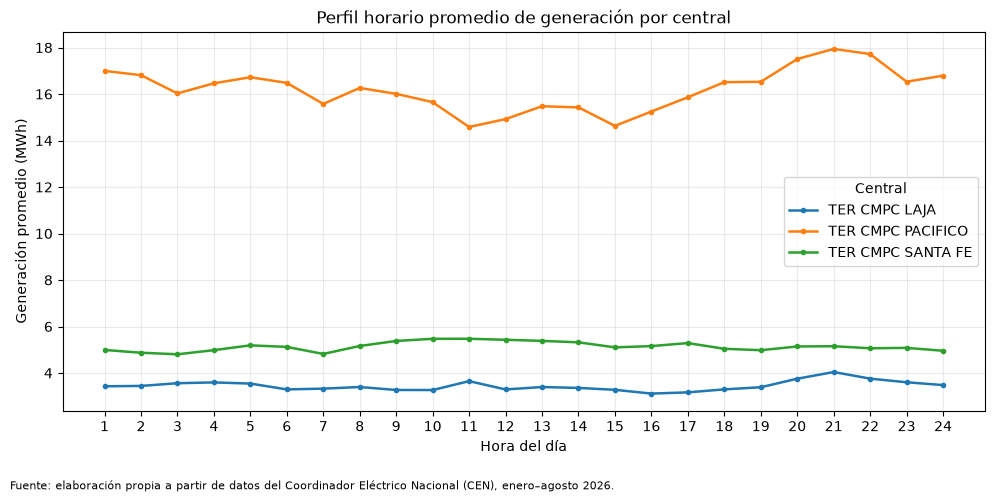

In [22]:
columna_horaria = resultado_horario.name

fig, ax = plt.subplots(figsize=(10, 5))

for central, datos in perfil_horario.groupby("Central"):
    datos = datos.sort_values("Hora")
    ax.plot(
        datos["Hora"],
        datos[columna_horaria],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=central,
    )

ax.set_title("Perfil horario promedio de generación por central")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Generación promedio (MWh)")
ax.set_xticks(range(1, 25))
ax.grid(alpha=0.25)
ax.legend(title="Central")

fig.text(
    0.01, 0.01,
    "Fuente: elaboración propia a partir de datos del Coordinador Eléctrico Nacional (CEN), enero–agosto 2026.",
    ha="left", fontsize=8,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


**Interpretación.** El perfil horario promedio muestra que las diferencias entre centrales son más marcadas en el **nivel de generación** que en la forma intradiaria de las curvas. TER CMPC Pacífico mantiene los valores promedio más altos durante las 24 horas, TER CMPC Santa Fe se ubica en un nivel intermedio y TER CMPC Laja presenta los valores más bajos. En las tres centrales las variaciones entre horas son relativamente acotadas frente a las diferencias existentes entre centrales. Por lo tanto, para el período analizado no se observa un ciclo intradiario común de gran amplitud; predomina la diferenciación entre centrales. Esta lectura es descriptiva y no permite atribuir causas operacionales a las variaciones observadas.


### 4.3 Evolución diaria

La agregación diaria corresponde a la **generación total por central y fecha**. Incorporar esta visualización fortalece el objetivo específico 1, ya que permite observar directamente la evolución durante los 243 días del período y no solamente los resúmenes horario y mensual.


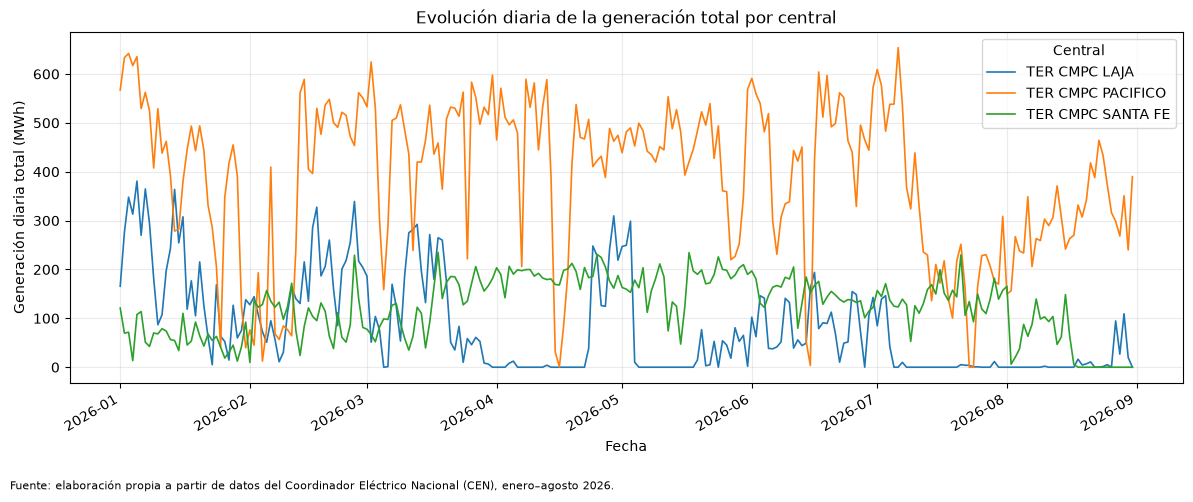

In [23]:
columna_diaria = resultado_diario.name

fig, ax = plt.subplots(figsize=(12, 5))

for central, datos in perfil_diario.groupby("Central"):
    datos = datos.sort_values("Fecha")
    ax.plot(
        datos["Fecha"],
        datos[columna_diaria],
        linewidth=1.2,
        label=central,
    )

ax.set_title("Evolución diaria de la generación total por central")
ax.set_xlabel("Fecha")
ax.set_ylabel("Generación diaria total (MWh)")
ax.grid(alpha=0.25)
ax.legend(title="Central")

fig.autofmt_xdate()
fig.text(
    0.01, 0.01,
    "Fuente: elaboración propia a partir de datos del Coordinador Eléctrico Nacional (CEN), enero–agosto 2026.",
    ha="left", fontsize=8,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


**Interpretación.** La evolución diaria evidencia una variabilidad temporal que queda oculta en los promedios horarios. TER CMPC Pacífico presenta, en gran parte del período, los mayores totales diarios, aunque con descensos pronunciados en fechas específicas y niveles más bajos hacia parte de julio y agosto. TER CMPC Laja muestra una trayectoria más discontinua, con varios intervalos de generación diaria muy baja o nula, especialmente en distintos tramos desde abril y hacia julio–agosto. TER CMPC Santa Fe presenta una trayectoria intermedia, con mayores niveles relativos durante buena parte de abril–julio y una disminución marcada hacia agosto. Estas trayectorias describen los datos observados; la fuente utilizada no permite establecer las causas operacionales de los cambios.


### 4.4 Evolución mensual

La agregación mensual corresponde a la **generación total por central y mes**. Esta escala facilita la comparación sintética de enero a agosto de 2026 y permite identificar cambios temporales de mayor duración.


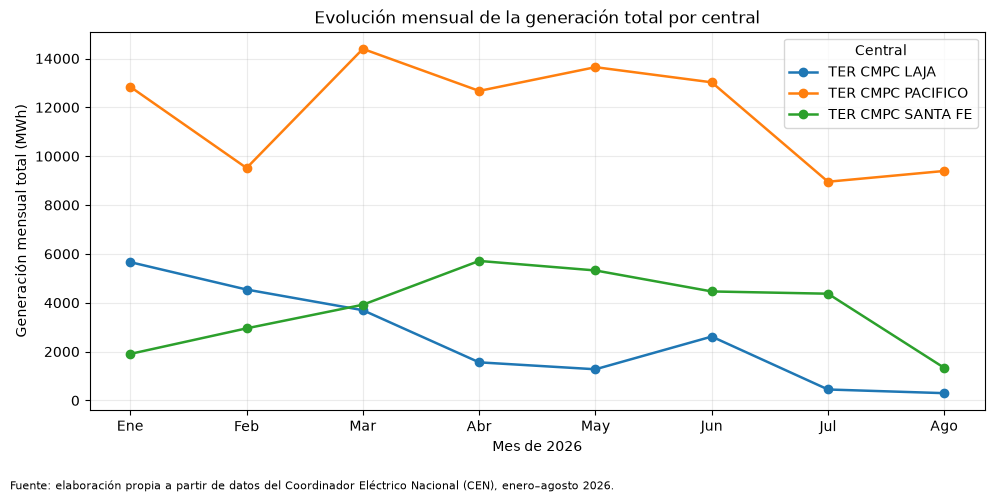

In [24]:
columna_mensual = resultado_mensual.name

fig, ax = plt.subplots(figsize=(10, 5))

for central, datos in perfil_mensual.groupby("Central", observed=True):
    datos = datos.sort_values("Mes")
    ax.plot(
        datos["Mes"].astype(str),
        datos[columna_mensual],
        marker="o",
        linewidth=1.8,
        label=central,
    )

ax.set_title("Evolución mensual de la generación total por central")
ax.set_xlabel("Mes de 2026")
ax.set_ylabel("Generación mensual total (MWh)")
ax.grid(alpha=0.25)
ax.legend(title="Central")

fig.text(
    0.01, 0.01,
    "Fuente: elaboración propia a partir de datos del Coordinador Eléctrico Nacional (CEN), enero–agosto 2026.",
    ha="left", fontsize=8,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


**Interpretación.** La escala mensual evidencia trayectorias claramente diferenciadas. TER CMPC Pacífico mantiene el mayor total mensual durante los ocho meses, con un máximo de 14.394,1 MWh en marzo. TER CMPC Laja pasa de 5.662,2 MWh en enero a 298,0 MWh en agosto, con una disminución especialmente marcada en julio y agosto. TER CMPC Santa Fe aumenta desde 1.905,3 MWh en enero hasta 5.712,3 MWh en abril, se mantiene sobre 4.000 MWh entre mayo y julio y disminuye a 1.333,0 MWh en agosto. La agregación mensual resume tendencias del período, pero no explica las causas de las variaciones.


### 4.5 Perfil por día de la semana — análisis complementario

Como complemento de las escalas horaria, diaria y mensual, se utiliza la estrategia `AgregacionPorDiaSemana` desarrollada en F3. Esta visualización permite comprobar si los promedios presentan diferencias sistemáticas entre días de la semana. Se interpreta como análisis descriptivo complementario y no como evidencia de causalidad.


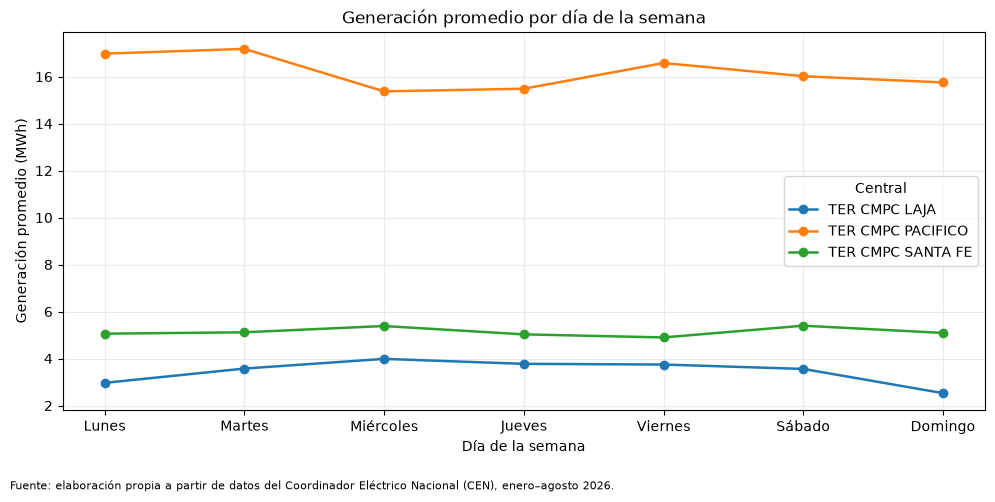

In [25]:
columna_dia_semana = resultado_dia_semana.name
orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

perfil_dia_semana["Dia_Semana"] = pd.Categorical(
    perfil_dia_semana["Dia_Semana"],
    categories=orden_dias,
    ordered=True,
)
perfil_dia_semana = perfil_dia_semana.sort_values(["Central", "Dia_Semana"])

fig, ax = plt.subplots(figsize=(10, 5))

for central, datos in perfil_dia_semana.groupby("Central", observed=True):
    ax.plot(
        datos["Dia_Semana"].astype(str),
        datos[columna_dia_semana],
        marker="o",
        linewidth=1.8,
        label=central,
    )

ax.set_title("Generación promedio por día de la semana")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Generación promedio (MWh)")
ax.grid(alpha=0.25)
ax.legend(title="Central")

fig.text(
    0.01, 0.01,
    "Fuente: elaboración propia a partir de datos del Coordinador Eléctrico Nacional (CEN), enero–agosto 2026.",
    ha="left", fontsize=8,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


**Criterio de lectura.** Este perfil debe evaluarse comparando la magnitud de las diferencias entre días dentro de cada central. Si las curvas se mantienen relativamente estables, no corresponde afirmar la existencia de un efecto semanal relevante solo por pequeñas diferencias visuales. La conclusión debe mantenerse descriptiva y consistente con el alcance del estudio.


## 5. Objetivo específico 2 — Comparación de patrones temporales

**Objetivo:** Comparar los patrones temporales de generación entre las tres centrales.

Las figuras horaria, diaria y mensual utilizan escalas temporales comunes y permiten contrastar tanto la forma de los perfiles como los niveles de generación observados. Para complementar la lectura visual se presenta una tabla mensual comparativa.


In [26]:
comparacion_mensual = (
    perfil_mensual
    .pivot(index="Mes", columns="Central", values=columna_mensual)
    .reindex(orden_meses)
)

display(comparacion_mensual.round(1))


Central,TER CMPC LAJA,TER CMPC PACIFICO,TER CMPC SANTA FE
Mes,,,
Ene,5662.2,12840.9,1905.3
Feb,4540.3,9516.6,2952.1
Mar,3695.0,14394.1,3919.0
Abr,1560.2,12673.3,5712.3
May,1276.2,13645.4,5322.1
Jun,2615.1,13024.9,4462.6
Jul,448.6,8954.7,4369.9
Ago,298.0,9395.9,1333.0


**Interpretación comparativa.** La tabla mensual confirma que TER CMPC Pacífico registra la mayor generación total en todos los meses analizados. Su máximo mensual se observa en marzo (14.394,1 MWh) y sus menores totales en julio (8.954,7 MWh) y agosto (9.395,9 MWh). TER CMPC Laja disminuye desde 5.662,2 MWh en enero hasta 298,0 MWh en agosto, aunque presenta un repunte en junio (2.615,1 MWh). TER CMPC Santa Fe aumenta desde 1.905,3 MWh en enero hasta un máximo de 5.712,3 MWh en abril, mantiene valores superiores a 4.000 MWh entre mayo y julio y disminuye a 1.333,0 MWh en agosto. En conjunto, las trayectorias mensuales muestran patrones temporales diferenciados entre las tres centrales, sin que estas diferencias permitan inferir por sí solas explicaciones técnicas u operacionales.


## 6. Objetivo específico 3 — Frecuencia y distribución temporal de registros de 0 MWh

**Objetivo:** Caracterizar la frecuencia y distribución temporal de los registros de generación igual a `0 MWh`, sin atribuirles una causa operacional no respaldada por la fuente.

El análisis se realiza en dos niveles complementarios:

1. frecuencia y porcentaje de registros `0 MWh` por central y mes;
2. secuencias consecutivas de `0 MWh` por central, reutilizando el algoritmo iterativo desarrollado en F3.

La continuidad temporal se analiza únicamente como patrón de datos.


In [27]:
ceros_mensuales = (
    df.assign(Es_Cero=df["Generacion_MWh"].eq(0))
      .groupby(["Central", "Mes"], observed=True)["Es_Cero"]
      .agg(Registros_Cero="sum", Total_Registros="count")
      .reset_index()
)

ceros_mensuales["Porcentaje_Cero"] = (
    ceros_mensuales["Registros_Cero"]
    / ceros_mensuales["Total_Registros"]
    * 100
).round(2)

ceros_mensuales["Mes"] = pd.Categorical(
    ceros_mensuales["Mes"],
    categories=orden_meses,
    ordered=True,
)

ceros_mensuales = ceros_mensuales.sort_values(["Central", "Mes"])

display(ceros_mensuales)


,Central,Mes,Registros_Cero,Total_Registros,Porcentaje_Cero
2,TER CMPC LAJA,Ene,148,744,19.89
3,TER CMPC LAJA,Feb,103,672,15.33
6,TER CMPC LAJA,Mar,274,744,36.83
0,TER CMPC LAJA,Abr,539,720,74.86
7,TER CMPC LAJA,May,565,744,75.94
5,TER CMPC LAJA,Jun,220,720,30.56
4,TER CMPC LAJA,Jul,659,744,88.58
1,TER CMPC LAJA,Ago,685,744,92.07
10,TER CMPC PACIFICO,Ene,80,744,10.75
11,TER CMPC PACIFICO,Feb,62,672,9.23


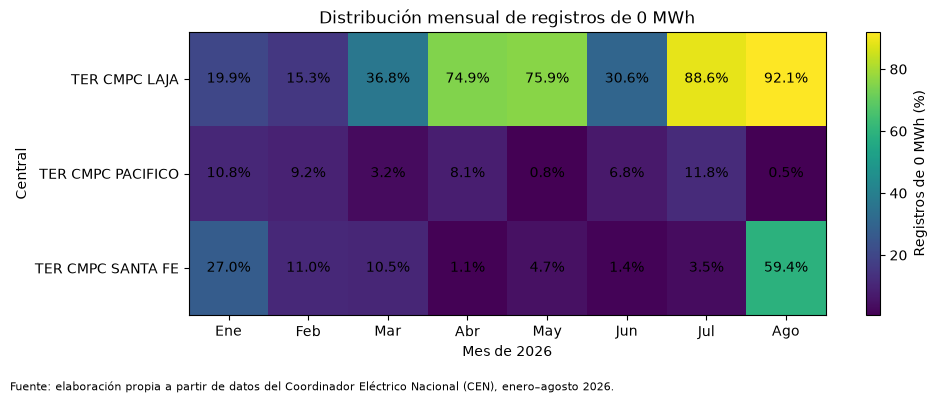

In [28]:
matriz_ceros = (
    ceros_mensuales
    .pivot(index="Central", columns="Mes", values="Porcentaje_Cero")
    .reindex(columns=orden_meses)
)

fig, ax = plt.subplots(figsize=(10, 4))
imagen = ax.imshow(matriz_ceros.values, aspect="auto")

ax.set_title("Distribución mensual de registros de 0 MWh")
ax.set_xlabel("Mes de 2026")
ax.set_ylabel("Central")
ax.set_xticks(range(len(matriz_ceros.columns)))
ax.set_xticklabels(matriz_ceros.columns)
ax.set_yticks(range(len(matriz_ceros.index)))
ax.set_yticklabels(matriz_ceros.index)

for i in range(matriz_ceros.shape[0]):
    for j in range(matriz_ceros.shape[1]):
        valor = matriz_ceros.iloc[i, j]
        ax.text(j, i, f"{valor:.1f}%", ha="center", va="center")

barra = fig.colorbar(imagen, ax=ax)
barra.set_label("Registros de 0 MWh (%)")

fig.text(
    0.01, 0.01,
    "Fuente: elaboración propia a partir de datos del Coordinador Eléctrico Nacional (CEN), enero–agosto 2026.",
    ha="left", fontsize=8,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


**Interpretación.** La distribución mensual confirma que los registros `0 MWh` no son homogéneos en el tiempo. En Laja, la proporción aumenta a 74,86 % en abril y 75,94 % en mayo, disminuye a 30,56 % en junio y alcanza 88,58 % en julio y 92,07 % en agosto. Pacífico mantiene porcentajes comparativamente bajos durante todo el período, entre 0,54 % y 11,83 %. Santa Fe presenta porcentajes bajos entre abril y julio, pero aumenta a 59,41 % en agosto. Estas concentraciones temporales describen cuándo se observan los registros iguales a cero, sin establecer su causa.


### 6.1 Secuencias consecutivas de 0 MWh

F4 reutiliza `analizar_secuencias_por_central()` de F3 para resumir la continuidad temporal de los registros iguales a `0 MWh`. Se utiliza la implementación iterativa, adecuada para procesar la serie completa sin las restricciones de profundidad de recursión de Python.


In [29]:
resumen_secuencias = analizar_secuencias_por_central(df)
display(resumen_secuencias)


,Central,numero_secuencias,duracion_maxima_horas,duracion_promedio_horas,total_horas_cero_en_secuencias
0,TER CMPC LAJA,211,375,15.132701,3193
1,TER CMPC PACIFICO,76,57,4.881579,371
2,TER CMPC SANTA FE,196,356,4.459184,874


**Interpretación.** El análisis de secuencias complementa la frecuencia de registros `0 MWh`. TER CMPC Laja presenta 211 secuencias, una duración máxima de 375 horas y una duración promedio de 15,13 horas, concentrando 3.193 horas con generación igual a cero. TER CMPC Pacífico registra 76 secuencias, con un máximo de 57 horas y un promedio de 4,88 horas. TER CMPC Santa Fe presenta 196 secuencias, con una duración máxima de 356 horas y un promedio de 4,46 horas. En consecuencia, Laja no solo presenta la mayor proporción de registros `0 MWh`, sino también secuencias promedio más prolongadas. Santa Fe, aunque tiene una proporción global menor, contiene al menos una secuencia extensa. Estos indicadores caracterizan continuidad temporal y no identifican la causa operacional de los registros.


## 7. Objetivo específico 4 — Regularidades y diferencias temporales

**Objetivo:** Identificar regularidades y diferencias temporales relevantes que sirvan de base para las etapas posteriores de análisis e interpretación.

La síntesis integra nivel de generación, dispersión, frecuencia de registros `0 MWh` y rango observado. Las figuras horaria, diaria y mensual permiten contextualizar estos indicadores dentro de su dimensión temporal.


In [30]:
sintesis = resumen_centrales.copy()

sintesis["Rango_MWh"] = (
    sintesis["Maximo_MWh"] - sintesis["Minimo_MWh"]
).round(2)

sintesis = sintesis[[
    "Media_MWh",
    "Mediana_MWh",
    "Desv_Estandar_MWh",
    "Registros_Cero",
    "Porcentaje_Cero",
    "Rango_MWh",
]]

display(sintesis)


,Media_MWh,Mediana_MWh,Desv_Estandar_MWh,Registros_Cero,Porcentaje_Cero,Rango_MWh
Central,,,,,,
TER CMPC LAJA,3.45,0.0,4.94,3193,54.75,27.3
TER CMPC PACIFICO,16.19,17.8,7.92,371,6.36,33.2
TER CMPC SANTA FE,5.14,5.7,3.17,874,14.99,17.9


## 8. Resultados principales

El análisis permite responder la pregunta de investigación identificando **patrones temporales diferenciados** entre TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe durante enero–agosto de 2026.

En términos de nivel general, TER CMPC Pacífico presenta la mayor generación media (16,19 MWh), seguida por TER CMPC Santa Fe (5,14 MWh) y TER CMPC Laja (3,45 MWh). El perfil horario mantiene este orden durante las 24 horas y muestra que las diferencias entre centrales son mayores que las variaciones intradiarias observadas dentro de cada una.

La escala diaria revela una variabilidad que no se aprecia en los promedios horarios, mientras que la escala mensual permite identificar trayectorias diferenciadas. Pacífico mantiene el mayor total mensual durante todo el período; Laja muestra una disminución importante hacia julio–agosto; y Santa Fe alcanza sus mayores totales entre abril y mayo antes de disminuir en agosto.

Los registros de `0 MWh` tampoco se distribuyen uniformemente. Laja concentra 3.193 observaciones (54,75 %), Santa Fe 874 (14,99 %) y Pacífico 371 (6,36 %). La distribución mensual muestra concentraciones particularmente altas en Laja durante abril, mayo, julio y agosto, y en Santa Fe durante agosto. El análisis de secuencias confirma además diferencias en la continuidad temporal de estos registros.

En conjunto, los resultados muestran que las tres centrales poseen perfiles distintos en nivel, trayectoria temporal y presencia de registros `0 MWh`. Estas conclusiones son descriptivas y se restringen al período y a las centrales analizadas.


## 9. Discusión y limitaciones

La estructura homogénea del dataset —24 observaciones por central y fecha durante 243 días— permite comparar las tres centrales bajo una base temporal común. El uso conjunto de escalas horaria, diaria y mensual evita depender de un único nivel de agregación y permite distinguir entre patrones intradiarios, variaciones de corto plazo y trayectorias mensuales.

Los resultados muestran que una medida aislada puede ser insuficiente para caracterizar el comportamiento de una central. En Laja, por ejemplo, la mediana de `0 MWh` y el 54,75 % de registros iguales a cero aportan información que no queda completamente representada por la media de 3,45 MWh. Del mismo modo, el análisis de secuencias agrega una dimensión de continuidad temporal que no entrega por sí solo el porcentaje de ceros.

La principal limitación interpretativa es que la fuente contiene registros de generación eléctrica, pero no antecedentes suficientes para determinar las causas de cada variación o de los valores `0 MWh`. Por ello, no corresponde interpretar automáticamente estos registros como fallas, mantenciones o detenciones operacionales.

El estudio es descriptivo y no incorpora variables explicativas externas, pruebas causales ni modelos predictivos. Asimismo, sus conclusiones se restringen a enero–agosto de 2026 y a TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe; no deben extrapolarse automáticamente a otros períodos o centrales.


## 10. Conclusiones

La pregunta de investigación —qué patrones temporales caracterizan la generación eléctrica de las tres centrales seleccionadas durante enero–agosto de 2026— se responde mediante un análisis reproducible que integra las cuatro fases del proyecto.

**Objetivo específico 1.** La caracterización horaria, diaria y mensual muestra perfiles diferenciados. Pacífico mantiene el mayor nivel de generación, Santa Fe ocupa una posición intermedia y Laja presenta el menor nivel promedio. La escala diaria revela variaciones y períodos de baja generación que los promedios horarios no muestran, mientras que la escala mensual sintetiza cambios de mayor duración.

**Objetivo específico 2.** La comparación confirma que las diferencias entre centrales no se limitan al nivel de generación: también difieren sus trayectorias temporales. Pacífico lidera los totales mensuales durante todo el período; Laja disminuye marcadamente hacia julio–agosto; y Santa Fe alcanza sus mayores totales en abril–mayo antes de descender en agosto.

**Objetivo específico 3.** Los registros `0 MWh` presentan una distribución desigual. Laja concentra el 54,75 % de sus observaciones en cero, Santa Fe el 14,99 % y Pacífico el 6,36 %. El análisis mensual y de secuencias consecutivas muestra, además, diferencias en la concentración y continuidad temporal de estos registros.

**Objetivo específico 4.** La integración de estadísticas descriptivas, escalas temporales y secuencias permite identificar regularidades y diferencias relevantes sin atribuir causas no respaldadas por la fuente.

Desde el punto de vista técnico, F4 reutiliza el dataset validado de F2 y los componentes desarrollados en F3 —validación modular, patrón Strategy y análisis de secuencias— evitando duplicar lógica y fortaleciendo la reproducibilidad y trazabilidad. En consecuencia, el proyecto mantiene continuidad entre problema, datos, código, resultados e interpretación final.


## 11. Trazabilidad F1 → F4

| Fase | Aporte al proyecto | Reutilización en F4 |
|---|---|---|
| **F1** | Problema, pregunta de investigación, objetivos, alcance y entorno reproducible. | Delimitación del análisis y criterios de interpretación. |
| **F2** | Selección reproducible de las tres centrales de celulosa, preparación, transformación y validación del dataset de Generación Real. | Dataset procesado de 17.496 observaciones y 13 variables. |
| **F3** | POO, pipeline de cuatro etapas, patrón Strategy, validación refactorizada, análisis de secuencias y eficiencia. | `validar_dataset_procesado()`, estrategias temporales y `analizar_secuencias_por_central()`. |
| **F4** | Integración, visualización, comparación, interpretación, discusión y conclusiones. | Respuesta consolidada a la pregunta y objetivos de investigación. |

El alcance analítico de F4 se mantiene sobre **TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe**, conforme a la selección definida en las fases previas. F4 no reincorpora centrales descartadas durante la delimitación inicial.

Esta secuencia mantiene la trazabilidad entre problema, alcance, datos, código, resultados y conclusiones.


## 12. Referencias y fuentes

- Coordinador Eléctrico Nacional. (2026). *Generación Real*. Fuente pública utilizada para la obtención de los datos del proyecto.
- Coordinador Eléctrico Nacional. (2022). *B43-DIN-04: Diccionario de Datos Web SIP*. Documento técnico utilizado para contextualizar la estructura de los datos.
- Python Software Foundation. *Python Documentation*.
- pandas development team. *pandas documentation*.
- Matplotlib Development Team. *Matplotlib documentation*.

> Para el informe formal, estas referencias deben completarse y normalizarse según APA 7 utilizando los datos bibliográficos y URL efectivamente consultados. No se incorporan referencias académicas adicionales en este notebook sin una fuente verificada.
